# Zadanie: analiza danych

Import niezbędnych bibliotek

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

Funkcja pomocnicza zwracajaca wiek pracownika 

In [176]:
def count_age(row):

    now = dt.datetime(2019,9,27)
    return int((now - row['DOB']).days / 365.25)

Funkcja pomocnicza zwracająca długość zatrudnienia

In [177]:
def count_seniority(row):

    if pd.isnull(row['DateofTermination']):
        end_date = dt.datetime(2019,9,27)
    else:
        end_date = row['DateofTermination']

    return (end_date - row['DateofHire']).days / 365.25


Pobieranie danych i usuniecie kolumn z dużą ilością braków danych

<Axes: >

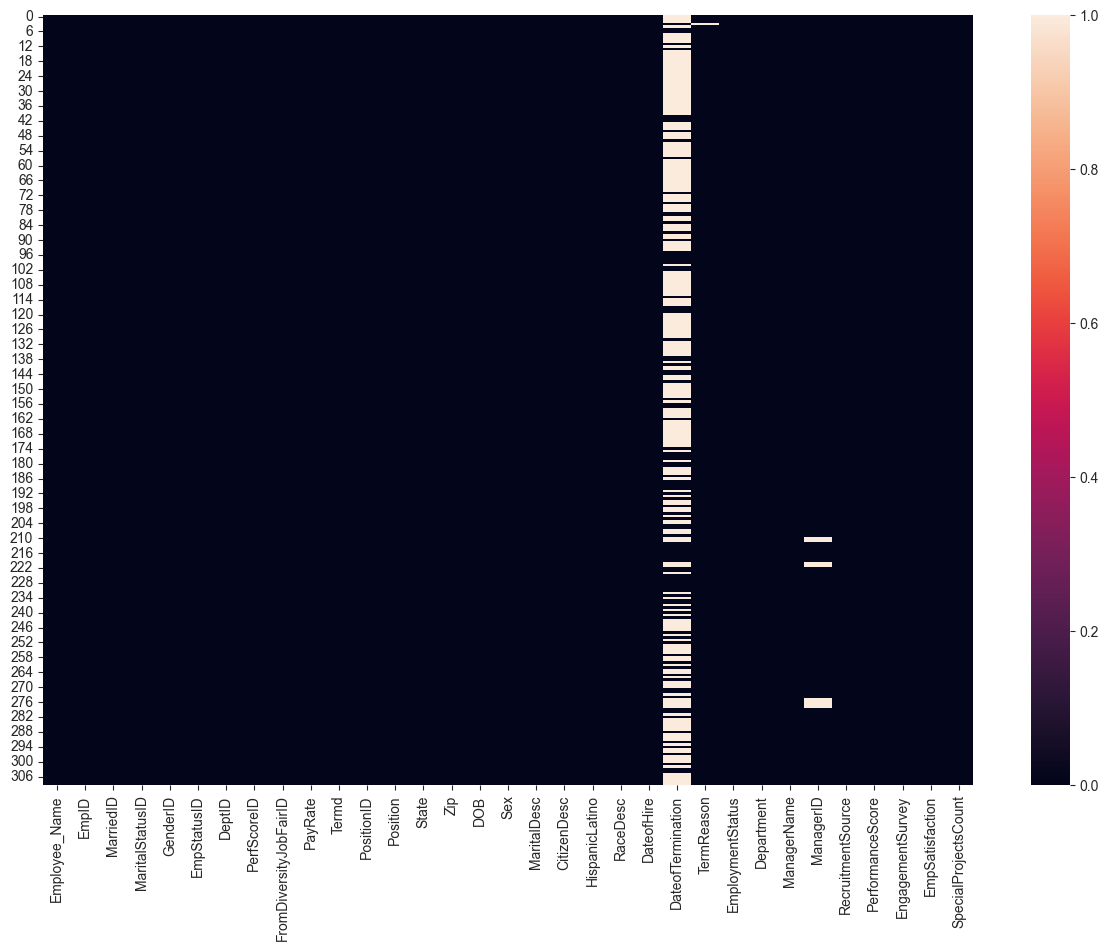

In [178]:
df = pd.read_csv('HRDataset.csv')
df.drop(['LastPerformanceReview_Date','DaysLateLast30'],axis=1,inplace=True)
df.dropna(thresh=2,inplace=True)

plt.figure(figsize=(15,10))
sns.heatmap(df.isnull())

Wizualne przedstawienie struktury danych. Braki w kolumnie DateofTermination wynikaja z tego ze kolumna t ajest uzupelniana tylko przy rozwiazaniu stosunku pracy.

Zmiana typy danych w kolumnach zawierających daty. Dodatkowo zabezpieczenie przed nieprawidlowym zapisem daty ktora była w formacie yy.mm.dd (kolumna DOB). Dodanie 2 kolumn Wiek oraz staż pracy.

In [ ]:
df['DOB'] = pd.to_datetime(df['DOB'],format='%m/%d/%y')
df['DOB'] = df['DOB'].apply(lambda x: x.replace(year=x.year - 100) if x.year > 2019 else x)
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'],format='%m/%d/%y')
df['DateofHire'] = pd.to_datetime(df['DateofHire'],format='%m/%d/%Y')
df['Seniority'] = df.apply(lambda row: count_seniority(row),axis=1)
df['Age'] = df.apply(lambda row: count_age(row),axis=1)

Określenie stylu sns

In [180]:
sns.set_style('ticks')

**AD 1**
Utworzenie crosstab w celu odszukania zależności między Przełożonym a oceną pracownika

In [194]:
scores_pct = pd.crosstab([df['ManagerID'],df['ManagerName']], df['PerformanceScore'], normalize='index')


Utworzenie wykresu słupkowego procentowe zestawienie ocen każdego menadżera.

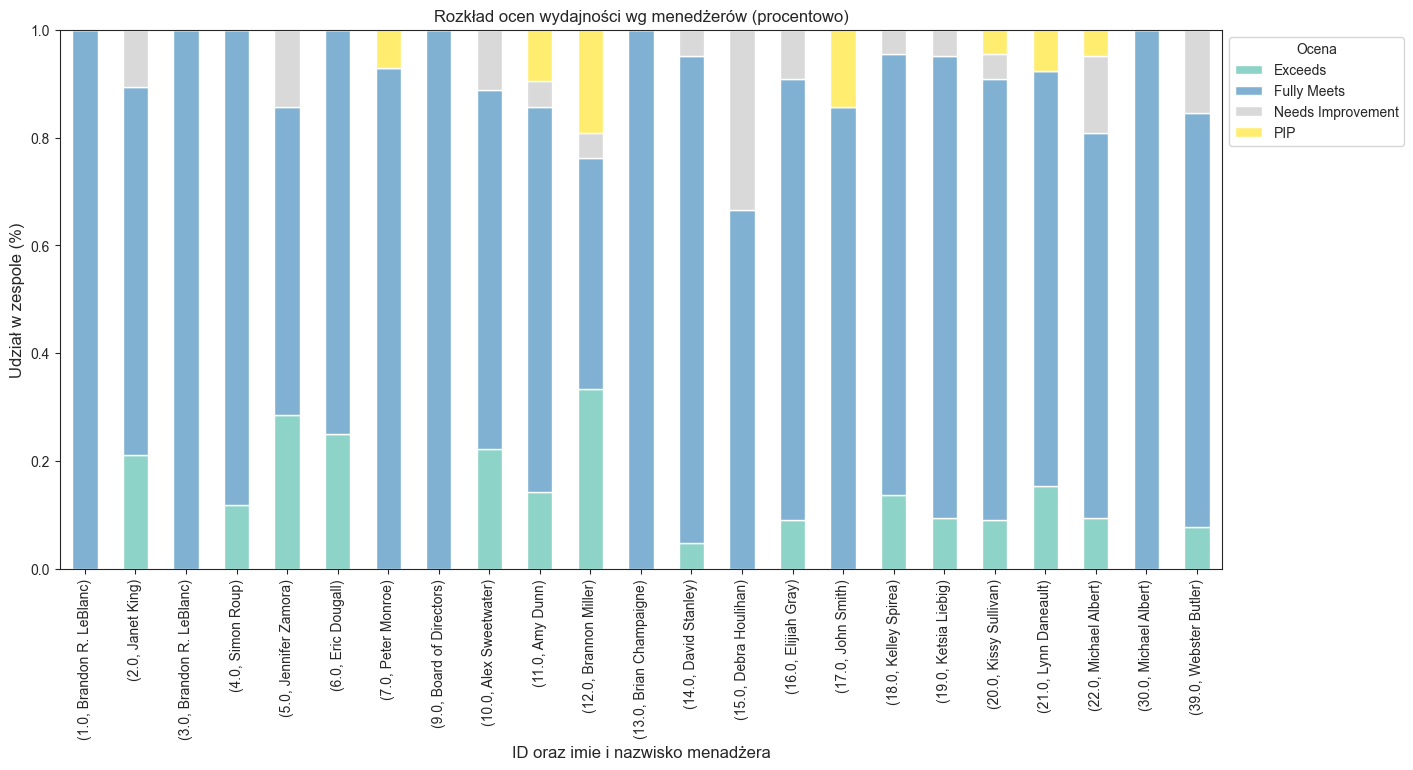

In [ ]:
scores_pct.plot(kind='bar', 
                stacked=True, 
                figsize=(15, 7), 
                colormap='Set3') 

plt.title('Rozkład ocen wydajności wg menedżerów (procentowo)')
plt.xlabel('ID oraz imie i nazwisko menadżera', fontsize=12)
plt.ylabel('Udział w zespole (%)', fontsize=12)
plt.legend(title='Ocena', bbox_to_anchor=(1, 1))
plt.show()

Na wykresie można zauważyć że poza menadżerem o id 12 nie można zauważyć większych odchyłów od normy. Wykres ten nie jest w stanie odpowiedzieć na pytanie czy istnieje zależność pomiędzy tym, kto jest bezpośrednim przełożonym a jego oceną wydajności.

Utworzenie dodatkowych tabel zawierajacych niezbedne informacje do udzielenia dokładniejszej odpowiedzi. Oraz połączenie ich w 1 duży raport.

In [ ]:
team_size = df.groupby(['ManagerID', 'ManagerName']).size().to_frame('TeamSize')
metrics = df.groupby(['ManagerID', 'ManagerName'])[['Seniority', 'PayRate', 'EmpSatisfaction', 'EngagementSurvey']].mean()
final_report = pd.concat([team_size, scores_pct, metrics], axis=1)


Dodanie do raportu wiersza ukazującego średnią z wyników dla każdego menadzera

In [196]:
final_report.loc[('ALL', 'COMPANY OVERALL'), :] = final_report.mean()
final_report

,,TeamSize,Exceeds,Fully Meets,Needs Improvement,PIP,Seniority,PayRate,EmpSatisfaction,EngagementSurvey
ManagerID,ManagerName,,,,,,,,,
1.0,Brandon R. LeBlanc,6.000000,0.000000,1.000000,0.000000,0.000000,4.699521,23.176667,3.500000,3.830000
2.0,Janet King,19.000000,0.210526,0.684211,0.105263,0.000000,5.691559,52.131579,3.631579,3.479474
3.0,Brandon R. LeBlanc,1.000000,0.000000,1.000000,0.000000,0.000000,4.610541,34.950000,4.000000,5.000000
4.0,Simon Roup,17.000000,0.117647,0.882353,0.000000,0.000000,2.830616,44.305882,3.823529,3.525294
5.0,Jennifer Zamora,7.000000,0.285714,0.571429,0.142857,0.000000,6.209446,52.214286,4.285714,3.135714
6.0,Eric Dougall,4.000000,0.250000,0.750000,0.000000,0.000000,8.361396,28.470000,3.500000,3.175000
7.0,Peter Monroe,14.000000,0.000000,0.928571,0.000000,0.071429,4.284736,44.957143,3.928571,3.316429
9.0,Board of Directors,2.000000,0.000000,1.000000,0.000000,0.000000,8.980151,57.475000,3.000000,4.915000
10.0,Alex Sweetwater,9.000000,0.222222,0.666667,0.111111,0.000000,4.837782,51.072222,4.222222,2.492222


Odpowiedź na pytanie "Czy istnieje zależność pomiędzy tym, kto jest bezpośrednim przełożonym (ManagerName, ManagerID) danego pracownika, a oceną wydajności pracy (PerformanceScore)?" Jest taka że, bezpośrednia silna korelacja nie występuje, a wydajność pracy jest wynikiem wielu czynników. Jako przykad posłuzy tu Brannon Miller o ID 12. Jego podwładni mają najbardziej skrajne oceny, jednak z danych wynika że jego podwładni stanowią jedną z największych grup, o najdłuższym starzu w firmie, jednocześnie są jedną z najniżej opłacanych grup oraz ich zadowolenie z pracy jest poniżej średniej. Wszystkie te czynniki mogą mieć wpływ na wydajność pracy. 

**AD 2**  
tworzenie zestawienia źródeł pozyskania pracownika, średniego czasu pracy oraz liczby pozyskanych pracowników daną metodą.

In [187]:

ad_2_report = df.groupby(['RecruitmentSource']).agg({
    'Seniority': 'mean',
    'Employee_Name': 'count' 
}).rename(columns={'Employee_Name': 'TotalHires'}) # Zmieniamy nazwę na ładniejszą

ad_2_report.sort_values(by='Seniority', ascending=False)

,Seniority,TotalHires
RecruitmentSource,,
Careerbuilder,8.481862,1
Other,6.453114,9
Billboard,5.862765,16
MBTA ads,5.729516,17
Website Banner Ads,5.721476,13
Information Session,5.623546,4
Professional Society,5.437645,20
Employee Referral,5.025899,31
Pay Per Click - Google,5.009354,21


Z zestawienia wynika że najlepszymi źródłami są bilbordy, reklamy MBTA i reklamy w internecie. Które mają zbliżony poziom. Careerbuilder nie może być brany pod uwagę z powodu tylko 1 pracownika pozyskanego w ten sposób. 

**AD 3**  
Tworzenie tabeli stanów cywilnych oraz zadowolenia

In [189]:
ad_3_report = df.groupby(['MaritalDesc']).agg({
    'Seniority': 'mean',
    'EmpSatisfaction': 'mean', 
    'PayRate': 'mean',
    'Employee_Name': 'count' 
}).rename(columns={'Employee_Name': 'Total '})
ad_3_report

,Seniority,EmpSatisfaction,PayRate,Total
MaritalDesc,,,,
Divorced,3.875519,4.033333,26.616667,30
Married,4.560347,3.747967,31.783659,123
Separated,6.345197,3.833333,29.750000,12
Single,5.110728,3.970803,32.169343,137
Widowed,3.279945,4.250000,28.275000,8


dane wskazują na wyrużniającą się grupę wdów/wdowców o największym wskaźniku satysfakcji, jednak próba jest za mała by to stwierdzić z pewnością, wpływ na tą grupę może mieć też to że jest to grópa średnio z najkrótszym starzem więc możliwe że nie występuje jeszcze np wypalenie zawodowe. Mimo to usuwając z zestawienia grupy o małej wielkości (wdowcy i separacje) można zauważyć że osoby w małżeństwie są średnio mniej zadowolone od osób po rozwodach lub singli. 

**AD 4**  
przygotowanie danych poprzez usuniecie osób ktore już nie pracują

In [190]:

ad_4_report = df[df['Termd'] == 0]


Stworzenie histogramu przedstawiającego strukture wieku w firmie

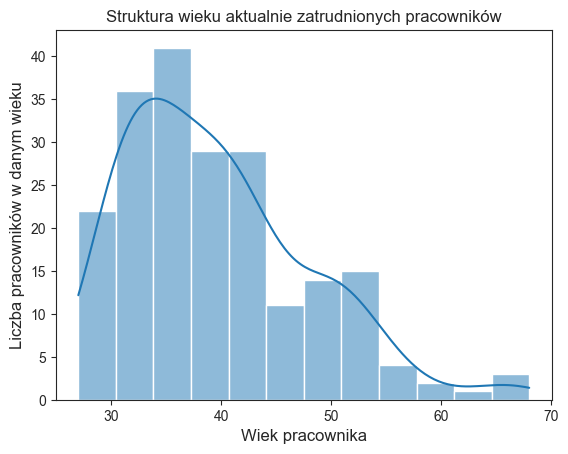

In [191]:
sns.histplot(ad_4_report['Age'], kde=True)
plt.title('Struktura wieku aktualnie zatrudnionych pracowników')
plt.xlabel('Wiek pracownika', fontsize=12)
plt.ylabel('Liczba pracowników w danym wieku', fontsize=12)
plt.show()

Struktura aktualnie zatrudnionych pracowników wskazuje na pracowników młodych lub w średnim wieku gdzie szczyt ilości osób w danym wieku przypada na około 35 lat. Powyżej 40 lat ilość pracowników drastycznie spada.

**AD 5**  
Tworzenie wykresu liniowego przedstawiajacego średnią ilość dodatkowych projektów wraz z wiekiem.

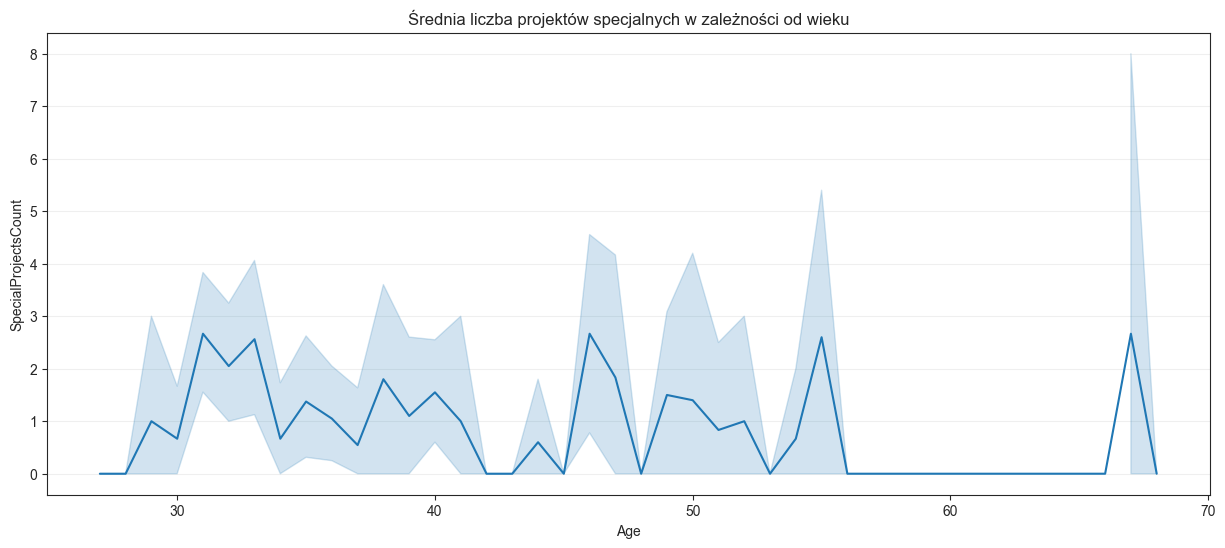

In [192]:
plt.figure(figsize=(15, 6))
# X to "co badamy", Y to "ile tego jest"
sns.lineplot(x='Age', y='SpecialProjectsCount', data=df)
plt.title('Średnia liczba projektów specjalnych w zależności od wieku')
plt.grid(axis='y', alpha=0.3)
plt.show()

Najmlodsi pracownicy nie robią dodatkowych projektów, prawdopodobnie z uwagi na wdrożenie, następnie ambitni 30-to latkowie robia więcej, poźniej zaangazowanie spada aż około 45 roku gdzie znowu mozna zauważyć wzrost zainteresowania dodatkowymi proejktami, jednak należy podkreślić że zgodnie z diagramem przedstawiajacym strukture wiekową pracowników w wieku ponad 45 lat jest juz dużo mniej a dane te nie są już aż tak wiarygodne. 